In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    CACHE_DIR = '/content/drive/MyDrive/dl_lab3_cache'
except ImportError:
    IN_COLAB = False
    CACHE_DIR = './dl_lab3_cache'

import os
os.makedirs(CACHE_DIR, exist_ok=True)
print("Cache directory:", CACHE_DIR)

Mounted at /content/drive
Cache directory: /content/drive/MyDrive/dl_lab3_cache


In [ ]:
import subprocess
import shutil
import matplotlib.font_manager as fm

FONT_CACHE = os.path.join(CACHE_DIR, "times.ttf")

def register_font(path, family_name="Times New Roman"):
    fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = family_name

if os.path.exists(FONT_CACHE):
    print("Found cached Times New Roman on Drive -- loading (fast path)...")
    register_font(FONT_CACHE)

else:
    print("No cached font found -- installing via apt-get (slow, one-time only)...")

    subprocess.run(
        'echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections',
        shell=True
    )

    result = subprocess.run(
        "apt-get update -qq && apt-get install -y ttf-mscorefonts-installer",
        shell=True,
        capture_output=True,
        text=True
    )

    print(result.stdout[-1000:])
    print(result.stderr[-1000:])

    subprocess.run("rm -rf ~/.cache/matplotlib", shell=True)
    subprocess.run("fc-cache -f", shell=True, capture_output=True)

    for f in fm.findSystemFonts():
        if "times" in f.lower():
            fm.fontManager.addfont(f)

    available = {f.name for f in fm.fontManager.ttflist}
    print("\nIs 'Times New Roman' actually installed?", "Times New Roman" in available)

    if "Times New Roman" in available:
        for f in fm.findSystemFonts():
            if "times" in f.lower() and f.lower().endswith((".ttf", ".ttc")):
                shutil.copy(f, FONT_CACHE)
                print(f"Cached font to {FONT_CACHE} for future runs.")
                break
        plt.rcParams["font.family"] = "Times New Roman"

    else:
        subprocess.run("apt-get install -y fonts-liberation", shell=True, capture_output=True)
        subprocess.run("rm -rf ~/.cache/matplotlib && fc-cache -f", shell=True, capture_output=True)

        for f in fm.findSystemFonts():
            if "liberationserif" in f.lower():
                fm.fontManager.addfont(f)
                shutil.copy(f, FONT_CACHE)
                break

        plt.rcParams["font.family"] = "Liberation Serif"
        print("Times New Roman unavailable -- using Liberation Serif instead.")

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.titlesize"] = 14

print("\nFinal font:", plt.rcParams["font.family"])

Found cached Times New Roman on Drive -- loading (fast path)...

Final font: ['Times New Roman']


In [ ]:
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save `fig` as {OUTPUT_DIR}/{name}.pdf at 600 DPI.

    Call this AFTER plt.tight_layout() and BEFORE plt.show(), e.g.:
        fig = plt.gcf()
        ...
        save_fig(fig, "my_plot")
        plt.show()
    """
    path = os.path.join(OUTPUT_DIR, f"{name}.pdf")
    fig.savefig(path, format="pdf", dpi=600, bbox_inches="tight")
    print(f"Saved figure -> {path}")

    if IN_COLAB:
        from google.colab import files
        files.download(path)

    return path

In [ ]:
CIFAR_CACHE = os.path.join(CACHE_DIR, "cifar10.npz")

if os.path.exists(CIFAR_CACHE):
    print("Loading CIFAR-10 from Drive cache...")
    data = np.load(CIFAR_CACHE)
    X_train, y_train = data["X_train"], data["y_train"]
    X_test, y_test = data["X_test"], data["y_test"]
else:
    print("No cache found -- downloading CIFAR-10 (one-time only)...")
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()
    np.savez(CIFAR_CACHE, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"Cached to {CIFAR_CACHE} for future runs.")

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Loading CIFAR-10 from Drive cache...
Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


In [ ]:
classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
           'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
print(classes)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


Saved figure -> figures/sample_images.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

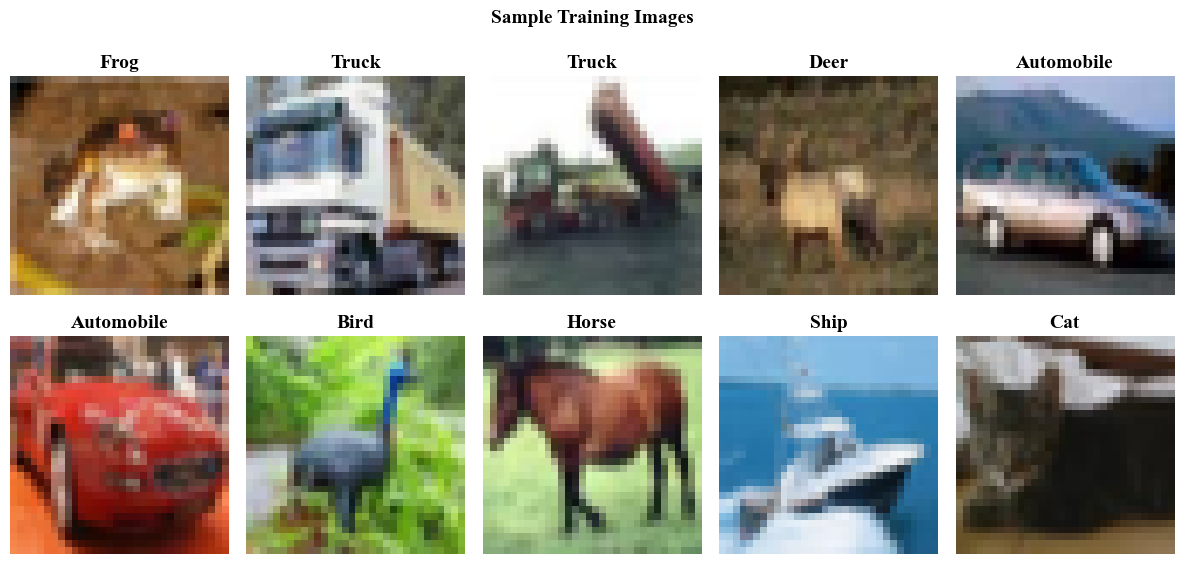

In [ ]:
fig = plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
save_fig(fig, "sample_images")
plt.show()

Saved figure -> figures/class_distribution.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

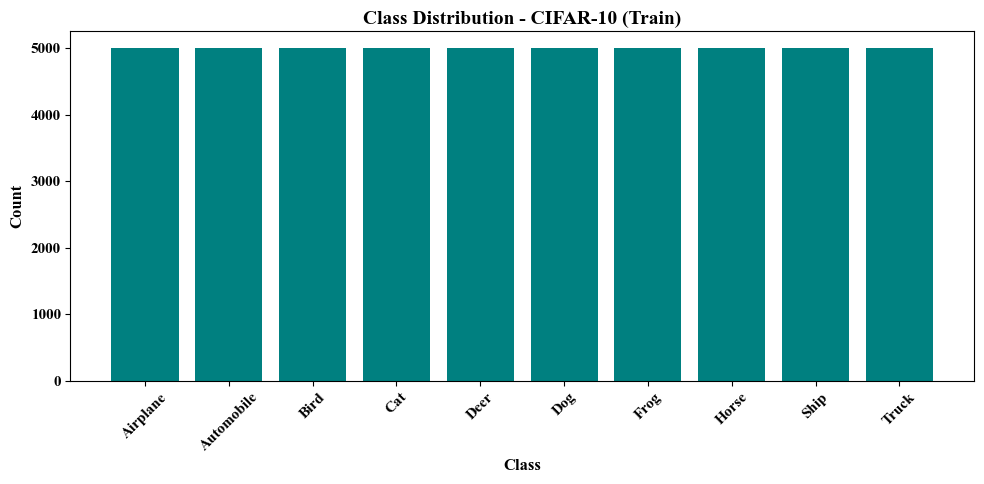

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

fig = plt.figure(figsize=(10, 5))
plt.bar([classes[u] for u in unique], counts, color="teal")
plt.xticks(rotation=45)
plt.title("Class Distribution - CIFAR-10 (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
save_fig(fig, "class_distribution")
plt.show()

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
print("Pixel value range after normalization:", X_train.min(), "to", X_train.max())

Pixel value range after normalization: 0.0 to 1.0


In [ ]:
def compute_output_size(N, F, P, S):
    """Output feature-map size using O = (N - F + 2P) / S + 1."""
    return int(np.floor((N - F + 2 * P) / S) + 1)

N = 32
S = 1
P = 0

print(f"{'Kernel':<10}{'Formula Output':<18}{'Conv2D Output Shape'}")
print("-" * 50)

sample = X_train[0:1]

for F in [3, 5, 7]:
    predicted = compute_output_size(N, F, P, S)

    conv = layers.Conv2D(filters=8, kernel_size=(F, F), strides=(S, S), padding='valid')
    out = conv(sample)

    print(f"{F}x{F:<8}{predicted:<18}{tuple(out.shape[1:3])}")

Kernel    Formula Output    Conv2D Output Shape
--------------------------------------------------
3x3       30                (30, 30)
5x5       28                (28, 28)
7x7       26                (26, 26)


In [ ]:
F = 3

print("Stride study (padding = 'valid', i.e. P = 0):")
print(f"{'Stride':<10}{'Formula Output':<18}{'Conv2D Output Shape'}")
print("-" * 50)
for S in [1, 2]:
    predicted = compute_output_size(N, F, P=0, S=S)
    conv = layers.Conv2D(filters=8, kernel_size=(F, F), strides=(S, S), padding='valid')
    out = conv(sample)
    print(f"{S:<10}{predicted:<18}{tuple(out.shape[1:3])}")

print()
print("Padding study (stride = 1):")
print(f"{'Padding':<10}{'Conv2D Output Shape'}")
print("-" * 50)
for pad in ['same', 'valid']:
    conv = layers.Conv2D(filters=8, kernel_size=(F, F), strides=(1, 1), padding=pad)
    out = conv(sample)
    print(f"{pad:<10}{tuple(out.shape[1:3])}")

print()
print("Note: Keras 'same' pads so output size = input size (stride 1);")
print("this corresponds to P = 1 for a 3x3 kernel in the O = (N-F+2P)/S + 1 formula:")
print("  O =", compute_output_size(N, F, P=1, S=1), " (matches 'same' padding above)")

Stride study (padding = 'valid', i.e. P = 0):
Stride    Formula Output    Conv2D Output Shape
--------------------------------------------------
1         30                (30, 30)
2         15                (15, 15)

Padding study (stride = 1):
Padding   Conv2D Output Shape
--------------------------------------------------
same      (32, 32)
valid     (30, 30)

Note: Keras 'same' pads so output size = input size (stride 1);
this corresponds to P = 1 for a 3x3 kernel in the O = (N-F+2P)/S + 1 formula:
  O = 32  (matches 'same' padding above)


In [ ]:
def build_cnn(kernel_size=(3, 3), stride=(1, 1), padding='same',
              filters=(16, 32), pool_type='max', optimizer='adam',
              activation='relu', dense_units=128,
              input_shape=(32, 32, 3), num_classes=10):
    """Build and compile a CNN with configurable hyperparameters."""

    Pool = layers.MaxPooling2D if pool_type == 'max' else layers.AveragePooling2D

    model = models.Sequential()

    model.add(layers.Conv2D(filters[0], kernel_size, strides=stride,
                             padding=padding, activation=activation,
                             input_shape=input_shape))
    model.add(Pool((2, 2)))

    for f in filters[1:]:
        model.add(layers.Conv2D(f, kernel_size, strides=stride,
                                 padding=padding, activation=activation))
        model.add(Pool((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation=activation))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,650 (1.02 MB)

 Trainable params: 268,650 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(f"{'Layer':<20}{'Output Shape':<25}{'Param #':<15}")
print("-" * 60)

total_params = 0
for layer in model.layers:
    n_params = layer.count_params()
    if n_params > 0:
        try:
            out_shape = str(layer.output.shape)
        except AttributeError:
            out_shape = "N/A"
        print(f"{layer.name:<20}{out_shape:<25}{n_params:<15,}")
        total_params += n_params

print("-" * 60)
print(f"Total trainable parameters: {total_params:,}")

Layer               Output Shape             Param #        
------------------------------------------------------------
conv2d_7            (None, 32, 32, 16)       448            
conv2d_8            (None, 16, 16, 32)       4,640          
dense               (None, 128)              262,272        
dense_1             (None, 10)               1,290          
------------------------------------------------------------
Total trainable parameters: 268,650


In [ ]:
QUICK_EPOCHS = 5
QUICK_BATCH = 32

def train_and_eval(m, epochs=QUICK_EPOCHS, batch_size=QUICK_BATCH, verbose=0):
    m.fit(X_train, y_train, validation_split=0.2,
          epochs=epochs, batch_size=batch_size, verbose=verbose)
    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    return loss, acc

def plot_results(results, title, xlabel, filename):
    fig = plt.figure(figsize=(6, 5))
    plt.bar(list(results.keys()), list(results.values()),
            color=['steelblue', 'indianred', 'seagreen', 'goldenrod'][:len(results)])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Test Accuracy")
    plt.ylim(0, 1)
    plt.tight_layout()
    save_fig(fig, filename)
    plt.show()

Pooling=max   -> Output size after pool 1: (16, 16)  Test Accuracy: 0.6645
Pooling=avg   -> Output size after pool 1: (16, 16)  Test Accuracy: 0.6534
Saved figure -> figures/pooling_comparison.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

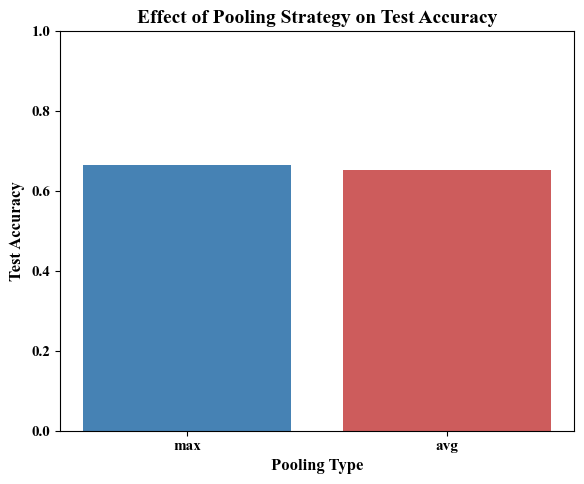

In [ ]:
pooling_results = {}
for pool in ['max', 'avg']:
    m = build_cnn(pool_type=pool)
    pooled_out_shape = tuple(m.layers[1].output.shape[1:3])
    loss, acc = train_and_eval(m)
    pooling_results[pool] = acc
    print(f"Pooling={pool:5s} -> Output size after pool 1: {pooled_out_shape}  "
          f"Test Accuracy: {acc:.4f}")

plot_results(pooling_results, "Effect of Pooling Strategy on Test Accuracy",
             "Pooling Type", "pooling_comparison")

In [ ]:
model = build_cnn()

BATCH_SIZE = 32
EPOCHS = 20

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss    :", test_loss)
print("Test Accuracy:", test_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4652 - loss: 1.4894 - val_accuracy: 0.5410 - val_loss: 1.2904
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5928 - loss: 1.1547 - val_accuracy: 0.5901 - val_loss: 1.1872
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6407 - loss: 1.0164 - val_accuracy: 0.6413 - val_loss: 1.0363
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6760 - loss: 0.9230 - val_accuracy: 0.6540 - val_loss: 1.0057
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7029 - loss: 0.8510 - val_accuracy: 0.6637 - val_loss: 0.9583
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7236 - loss: 0.7836 - val_accuracy: 0.6637 - val_loss: 0.9694
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7468 - loss: 0.7242 - val_accuracy: 0.6733 - val_loss: 0.9543
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7631 - loss: 0.6692 -

Saved figure -> figures/accuracy_curve.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

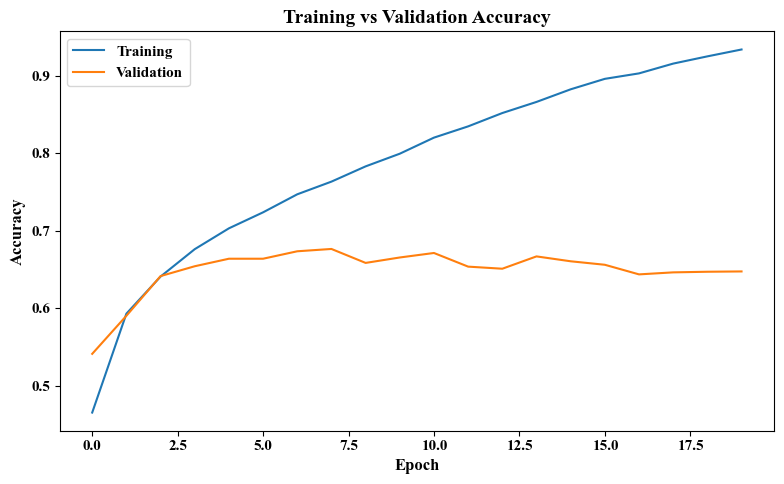

In [ ]:
fig = plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label="Training")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
save_fig(fig, "accuracy_curve")
plt.show()

Saved figure -> figures/loss_curve.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

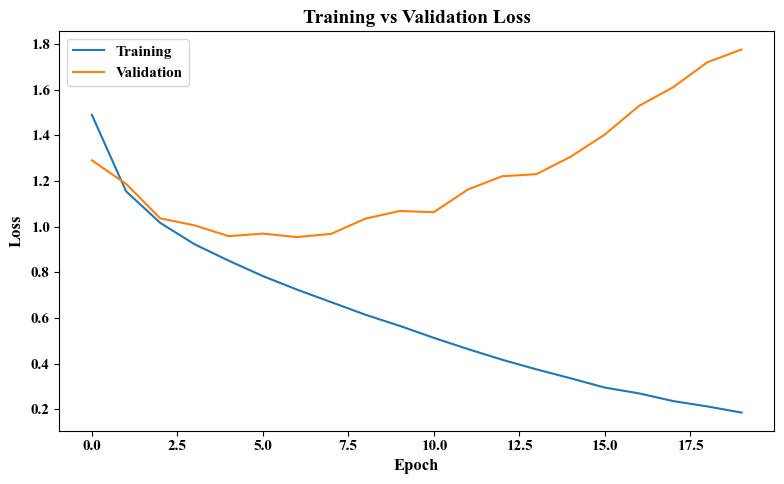

In [ ]:
fig = plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label="Training")
plt.plot(history.history['val_loss'], label="Validation")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
save_fig(fig, "loss_curve")
plt.show()

In [ ]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test.flatten()

print(classification_report(true_classes, predicted_classes, target_names=classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    Airplane       0.67      0.71      0.69      1000
  Automobile       0.74      0.75      0.75      1000
        Bird       0.54      0.47      0.50      1000
         Cat       0.48      0.40      0.44      1000
        Deer       0.61      0.56      0.59      1000
         Dog       0.55      0.55      0.55      1000
        Frog       0.67      0.76      0.71      1000
       Horse       0.72      0.70      0.71      1000
        Ship       0.74      0.80      0.77      1000
       Truck       0.68      0.74      0.71      1000

    accuracy                           0.65     10000
   macro avg       0.64      0.65      0.64     10000
weighted avg       0.64      0.65      0.64     10000



In [ ]:
precision = precision_score(true_classes, predicted_classes, average='weighted')
recall = recall_score(true_classes, predicted_classes, average='weighted')
f1 = f1_score(true_classes, predicted_classes, average='weighted')

print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Precision: 0.6398428412672525
Recall   : 0.6455
F1 Score : 0.6414233162660109


Saved figure -> figures/confusion_matrix.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

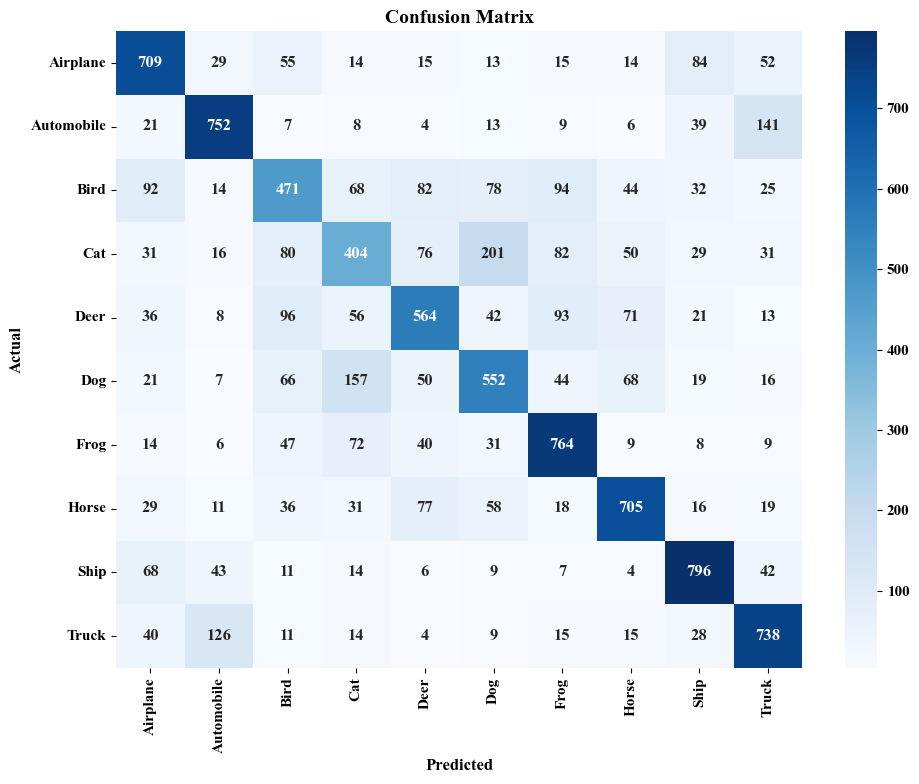

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

fig = plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
save_fig(fig, "confusion_matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Saved figure -> figures/feature_maps_conv1.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

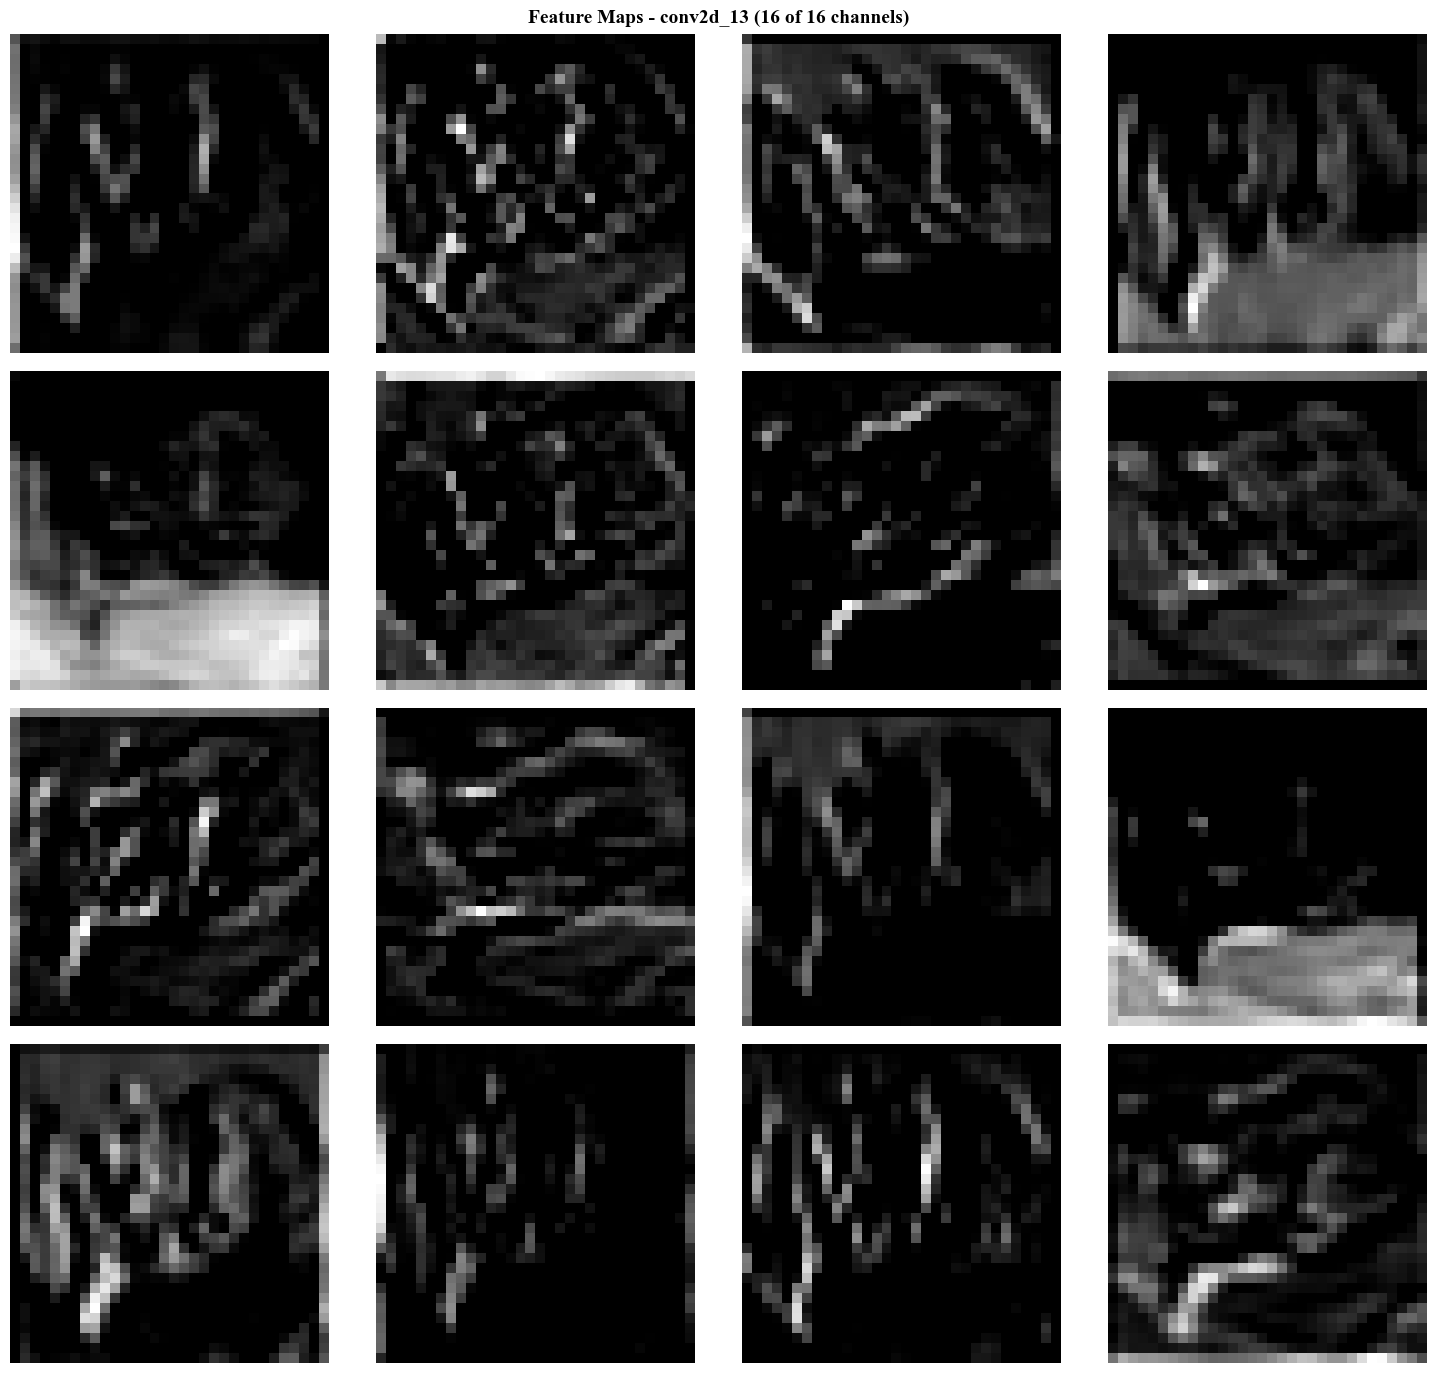

In [ ]:
first_conv = [l for l in model.layers if isinstance(l, layers.Conv2D)][0]
activation_model = Model(inputs=model.inputs, outputs=first_conv.output)

sample_img = X_test[0:1]
activation = activation_model.predict(sample_img)

n_features = min(16, activation.shape[-1])
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig = plt.figure(figsize=(15, 3.5 * n_rows))
for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(activation[0, :, :, i], cmap='gray')
    plt.axis("off")
plt.suptitle(f"Feature Maps - {first_conv.name} ({n_features} of {activation.shape[-1]} channels)")
plt.tight_layout()
save_fig(fig, "feature_maps_conv1")
plt.show()

Conv1 filter tensor shape: (3, 3, 3, 16)
Saved figure -> figures/conv1_filters.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

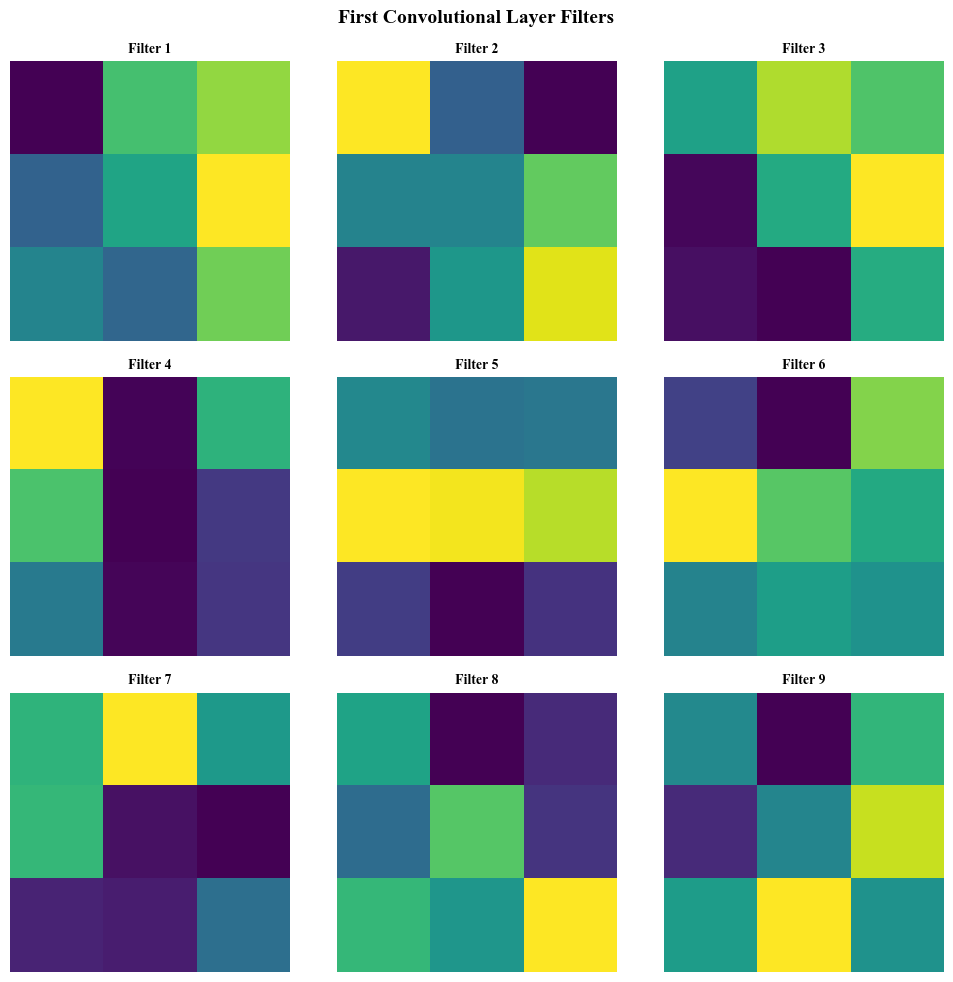

In [ ]:
filters_w, biases = model.layers[0].get_weights()
print("Conv1 filter tensor shape:", filters_w.shape)

f_min, f_max = filters_w.min(), filters_w.max()
filters_norm = (filters_w - f_min) / (f_max - f_min)

n_filters = min(9, filters_norm.shape[-1])
fig = plt.figure(figsize=(10, 10))
for i in range(n_filters):
    f = filters_norm[:, :, :, i]
    plt.subplot(3, 3, i + 1)
    plt.imshow(f[:, :, 0], cmap='viridis')
    plt.axis("off")
    plt.title(f"Filter {i + 1}", fontsize=10)
plt.suptitle("First Convolutional Layer Filters")
plt.tight_layout()
save_fig(fig, "conv1_filters")
plt.show()

In [ ]:
N_ex, F_ex, S_ex, P_ex = 64, 5, 2, 2
O_ex = compute_output_size(N_ex, F_ex, P_ex, S_ex)
print(f"O = (N - F + 2P)/S + 1 = ({N_ex} - {F_ex} + 2*{P_ex})/{S_ex} + 1 = {O_ex}")

O = (N - F + 2P)/S + 1 = (64 - 5 + 2*2)/2 + 1 = 32


In [ ]:
filters_ex, kernel_ex, channels_ex = 64, 3, 3
params_ex = (kernel_ex * kernel_ex * channels_ex + 1) * filters_ex
print(f"Params = (F*F*C + 1) * K = ({kernel_ex}*{kernel_ex}*{channels_ex} + 1) * {filters_ex} = {params_ex:,}")

conv_check = layers.Conv2D(filters_ex, (kernel_ex, kernel_ex), padding='valid',
                            input_shape=(32, 32, channels_ex))
conv_check.build((None, 32, 32, channels_ex))
print("Keras Conv2D reports:", conv_check.count_params(), "parameters")

Params = (F*F*C + 1) * K = (3*3*3 + 1) * 64 = 1,792
Keras Conv2D reports: 1792 parameters


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Activation=relu     -> Test Accuracy: 0.6713
Activation=sigmoid  -> Test Accuracy: 0.4909
Saved figure -> figures/activation_comparison.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

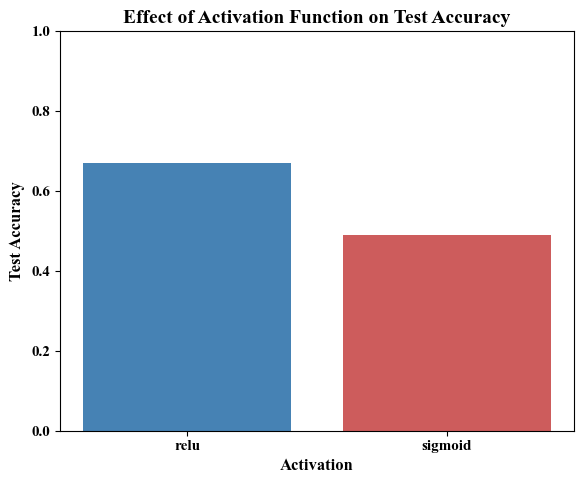

In [ ]:
activation_results = {}
for act in ['relu', 'sigmoid']:
    m = build_cnn(activation=act)
    loss, acc = train_and_eval(m)
    activation_results[act] = acc
    print(f"Activation={act:8s} -> Test Accuracy: {acc:.4f}")

plot_results(activation_results, "Effect of Activation Function on Test Accuracy",
             "Activation", "activation_comparison")

In [ ]:
print("See Task 5 above:", pooling_results)

See Task 5 above: {'max': 0.6644999980926514, 'avg': 0.6534000039100647}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Filters=(16, 32) -> Test Accuracy: 0.6691   Training Time: 31.3s
Filters=(64, 128) -> Test Accuracy: 0.6970   Training Time: 37.4s
Saved figure -> figures/filters_accuracy_vs_time.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

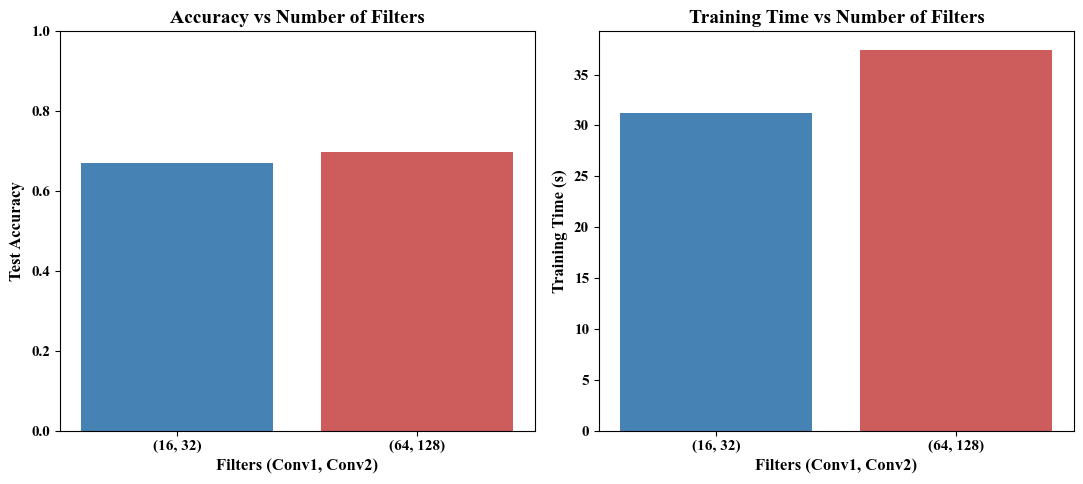

In [ ]:
filters_time_results = {}
filters_acc_results = {}

for f in [(16, 32), (64, 128)]:
    m = build_cnn(filters=f)
    start = time.time()
    loss, acc = train_and_eval(m)
    elapsed = time.time() - start

    filters_time_results[str(f)] = elapsed
    filters_acc_results[str(f)] = acc
    print(f"Filters={f} -> Test Accuracy: {acc:.4f}   Training Time: {elapsed:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].bar(filters_acc_results.keys(), filters_acc_results.values(), color=['steelblue', 'indianred'])
axes[0].set_title("Accuracy vs Number of Filters")
axes[0].set_xlabel("Filters (Conv1, Conv2)")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(filters_time_results.keys(), filters_time_results.values(), color=['steelblue', 'indianred'])
axes[1].set_title("Training Time vs Number of Filters")
axes[1].set_xlabel("Filters (Conv1, Conv2)")
axes[1].set_ylabel("Training Time (s)")

plt.tight_layout()
save_fig(fig, "filters_accuracy_vs_time")
plt.show()

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Study": (
        ["Pooling"] * len(pooling_results) +
        ["Activation"] * len(activation_results) +
        ["Filters (accuracy)"] * len(filters_acc_results) +
        ["Filters (time, s)"] * len(filters_time_results)
    ),
    "Value": (
        list(pooling_results.keys()) + list(activation_results.keys()) +
        list(filters_acc_results.keys()) + list(filters_time_results.keys())
    ),
    "Result": (
        list(pooling_results.values()) + list(activation_results.values()) +
        list(filters_acc_results.values()) + list(filters_time_results.values())
    ),
})

summary

,Study,Value,Result
0,Pooling,max,0.664500
1,Pooling,avg,0.653400
2,Activation,relu,0.671300
3,Activation,sigmoid,0.490900
4,Filters (accuracy),"(16, 32)",0.669100
5,Filters (accuracy),"(64, 128)",0.697000
6,"Filters (time, s)","(16, 32)",31.259807
7,"Filters (time, s)","(64, 128)",37.380766
